In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob
import pandas as pd
from darksirenpop.utilities.utils import get_run, make_nice_plots
from darksirenpop.utilities.default_globals import *

make_nice_plots()

In [5]:
SKYMAP_STATS_PATH = f'{REWEIGHT_GWTC5_SKYMAP_STATS}/*.dat'

# $90\%$ CL localization volumes histogram

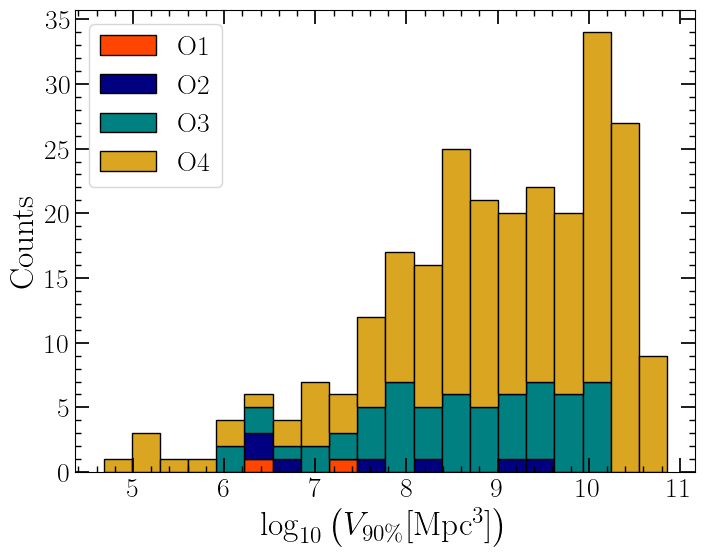

1146310458.9, -1143699382.7, +28846336524.4
9.1, -2.6, +1.4


In [6]:
v90_O1 = []
v90_O2 = []
v90_O3 = []
v90_O4 = []
all_v90 = []

# v90_O4b = []
# v90_except_O4b = []
for i, file in enumerate( sorted( glob.glob(SKYMAP_STATS_PATH) ) ):
    run = get_run(file.split('/')[-1].split('.')[0])

    stat = pd.read_csv(file, skiprows=1, delimiter='\t')
    vol90 = stat['vol(90)'].iloc[0] #/ stat['distmean'].iloc[0]
    all_v90.append(vol90)

    if run == 'O1':
        v90_O1.append(vol90)
    elif run == 'O2':
        v90_O2.append(vol90)
    elif run == 'O3':
        v90_O3.append(vol90)
    elif run == 'O4':
        v90_O4.append(vol90)

    # is_O4b = False
    # name = file.split('/')[-1].split('.')[0]
    # if int(name[2:4]) == 24:
    #     if int(name[2:4]) >= 4:
    #         is_O4b = True
    # elif int(name[2:4]) == 25:
    #     is_O4b = True

    # if is_O4b:
    #     v90_O4b.append(vol90)
    # else:
    #     v90_except_O4b.append(vol90)

v90 = [np.log10(v90_O1), np.log10(v90_O2), np.log10(v90_O3), np.log10(v90_O4)]
plt.figure(figsize=(8,6))
plt.hist(v90, bins=20, linewidth=1, edgecolor='black', stacked=True, facecolor=COLORS[:4], label=['O1', 'O2', 'O3', 'O4'])
plt.legend()
plt.xlabel(r'$\log_{10} \left( V_{90\%} [\mathrm{Mpc^{3}}] \right)$')
plt.ylabel('Counts')
# plt.savefig(f'{PLOT_DIR}/v90_histogram.pdf', bbox_inches='tight')
plt.show()

print(f'{np.quantile(all_v90, 0.5):.1f}, -{np.quantile(all_v90, 0.5) - np.quantile(all_v90, 0.05):.1f}, +{np.quantile(all_v90, 0.95) - np.quantile(all_v90, 0.5):.1f}')
print(f'{np.quantile(np.log10(all_v90), 0.5):.1f}, -{np.quantile(np.log10(all_v90), 0.5) - np.quantile(np.log10(all_v90), 0.05):.1f}, +{np.quantile(np.log10(all_v90), 0.95) - np.quantile(np.log10(all_v90), 0.5):.1f}')


# AGN observations as GW prior principle

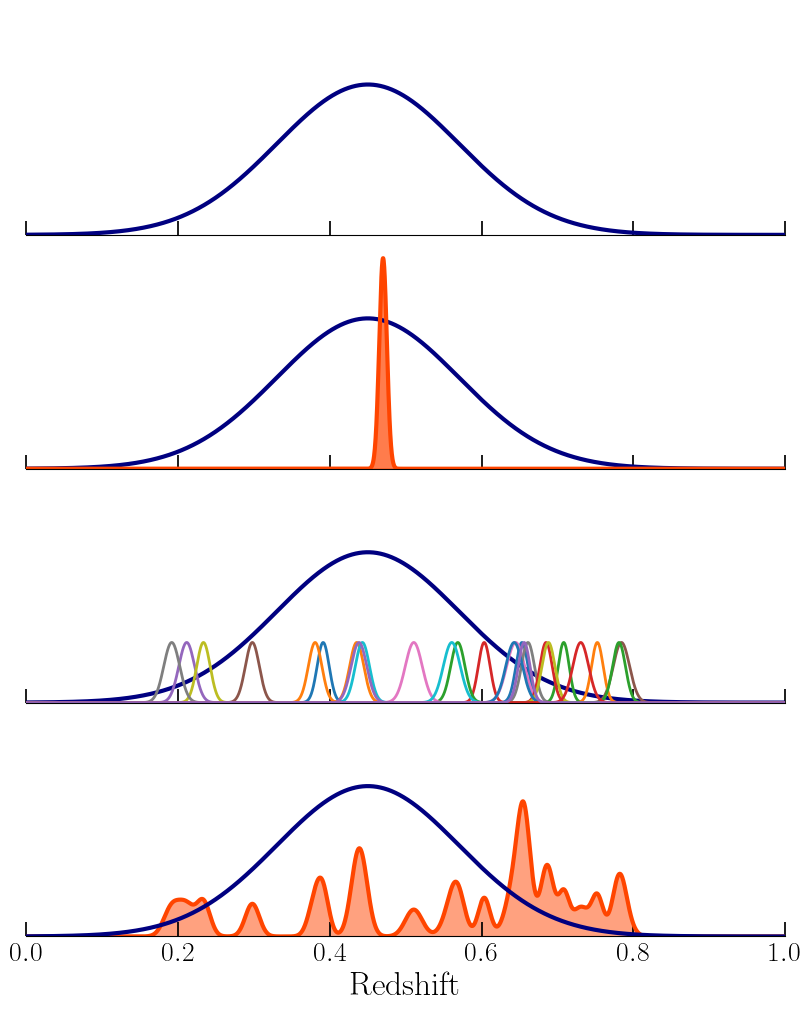

In [7]:
gwcolor = 'navy'
emcolor = 'orangered'
biglw = 3

# --------------------------------------------------
# Redshift grid
# --------------------------------------------------
z = np.linspace(0.0, 1.0, 3000)

fig, axes = plt.subplots(
    4, 1,
    figsize=(8, 10),
    sharex=True,
    constrained_layout=True
)

# ==================================================
# 1. Broad GW likelihood
# ==================================================
z_gw = 0.45
sigma_gw = 0.12

gw = norm.pdf(z, z_gw, sigma_gw)
gw /= gw.max()   # purely for visualization

# axes[0].fill_between(z, gw, alpha=0.5)
axes[0].plot(z, gw, lw=biglw, color=gwcolor)
axes[0].set_ylabel("")
axes[0].set_yticks([])
# axes[0].set_title("1. GW redshift likelihood")

# ==================================================
# 2. Add an EM counterpart
# ==================================================
sigma_em = 0.005
z_em = 0.47

em = norm.pdf(z, z_em, sigma_em)
em /= em.max() / 1.4

# axes[1].fill_between(z, gw, alpha=0.3, label="GW")
axes[1].plot(z, gw, lw=biglw, color=gwcolor)

axes[1].fill_between(
    z, em,
    alpha=0.7,
    color=emcolor)
axes[1].plot(z, em, lw=biglw, color=emcolor)

# axes[1].legend(frameon=False)
axes[1].set_yticks([])
# axes[1].set_title("2. GW likelihood + EM counterpart")

# ==================================================
# 3. Possible host galaxies
# ==================================================
rng = np.random.default_rng(42)

n_hosts = 25
host_means = rng.uniform(0.15, 0.8, n_hosts)
host_sigmas = rng.uniform(0.007, 0.012, n_hosts)

# axes[2].fill_between(z, gw, alpha=0.25)
axes[2].plot(z, gw, lw=biglw, color=gwcolor)

for mu, sig in zip(host_means, host_sigmas):
    g = norm.pdf(z, mu, sig)
    g /= g.max()
    axes[2].plot(z, 0.4 * g, lw=2)

axes[2].set_yticks([])
# axes[2].set_title("3. Candidate host galaxies")
# axes[2].legend(frameon=False)

# ==================================================
# 4. Construct the galaxy redshift prior
# ==================================================
prior = np.zeros_like(z)

for mu, sig in zip(host_means, host_sigmas):
    prior += norm.pdf(z, mu, sig)

# Proper normalization:
prior /= n_hosts * 8

axes[3].plot(z, prior, lw=biglw, color=emcolor)
axes[3].fill_between(z, prior, alpha=0.5, color=emcolor)

axes[3].plot(z, gw, lw=biglw, color='navy')

# # Optional: overlay individual hosts
# for mu, sig, w in zip(host_means, host_sigmas, weights):
#     g = w * norm.pdf(z, mu, sig)
#     g /= np.trapz(prior, z)
#     axes[3].plot(z, g, lw=0.7, alpha=0.3)

# axes[3].set_title("4. Galaxy redshift prior")
axes[3].set_yticks([])
axes[3].set_xlabel("Redshift")

for ax in axes:
    ax.set_xlim(0, 1)

for ax in axes:
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    
    ax.minorticks_off()
    ax.tick_params(axis='x', which='major', top=False)

    ax.set_ylim(0, 1.5)

# plt.savefig(f'{PLOT_DIR}/zprior_sketch.pdf', bbox_inches='tight')
plt.show()
